# Phase 1 — Data Parsing & Dataset Preparation
### Project: Predicting Protein Thermostability from Sequence Features
**Author:** Mauli Bhavsar  
**Date:** April 2026  

---

## What is this project about?

Proteins are the molecular machines of life. Every protein has a unique amino acid sequence, and that sequence determines everything about the protein — including how stable it is at high temperatures. 

A protein's **thermal stability** is measured by its **melting temperature (Tm)** — the temperature at which the protein unfolds and loses its function. Proteins from heat-loving organisms (thermophiles) have high Tm values and are called **thermostable**. Proteins from normal organisms have lower Tm values and are called **mesostable**.

In this project, we ask a fundamental question:

> **Can we predict whether a protein is thermostable or mesostable, just from its amino acid sequence?**

We will answer this using **machine learning** — training models to find patterns in sequence-derived features that distinguish thermostable from mesostable proteins.

---

## What does Phase 1 do?

Before any machine learning can happen, we need clean, labelled data. Phase 1 covers:

1. Loading the raw dataset (Meltome Atlas — Jarzab et al. 2020, *Nature Methods*)
2. Parsing protein sequences and their measured melting temperatures
3. Assigning binary labels (thermostable = 1, mesostable = 0)
4. Saving a clean dataset ready for feature engineering

---

## What is the Meltome Atlas?

The **Meltome Atlas** is a landmark dataset published in *Nature Methods* in 2020. Researchers measured melting temperatures for thousands of proteins across 13 different organisms using a technique called **Thermal Proteome Profiling (TPP)**. It is one of the largest and most systematic protein thermostability datasets ever created, making it ideal for machine learning.

In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
# These are all the libraries we need for this notebook.

# pandas: Python's most important data analysis library.
# Think of it as Excel inside Python — it gives us "DataFrames"
# which are tables with rows and columns, just like a spreadsheet.
import pandas as pd

# os: A built-in Python library for interacting with the file system.
# We use it to check if files/folders exist and to build file paths.
import os

# matplotlib and seaborn: Plotting libraries.
# matplotlib is the base plotting engine.
# seaborn is built on top of matplotlib and makes prettier statistical plots.
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent plot style for all figures in this notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1 — Load the cleaned dataset

We load the CSV file we created using `src/01_parse_data.py`. This file contains:

| Column | Description |
|--------|-------------|
| `protein_id` | Unique identifier for each protein |
| `sequence` | Amino acid sequence in single-letter code |
| `tm` | Experimentally measured melting temperature (°C) |
| `label` | 1 = Thermostable (Tm > 60°C), 0 = Mesostable (Tm < 45°C) |

We use `pd.read_csv()` to load it — this is the most common way to load any tabular data into Python.

In [3]:
# Load the cleaned dataset we created in src/01_parse_data.py
# pd.read_csv() reads any CSV file and turns it into a DataFrame
df = pd.read_csv('../data/processed/02_dataset_clean.csv')

# .shape tells us the dimensions of the table — (rows, columns)
print("Shape of dataset:", df.shape)

# .columns shows us all column names
print("Columns:", list(df.columns))

# .head() shows the first 5 rows — always do this to visually confirm
# the data loaded correctly
df.head()

Shape of dataset: (36100, 4)
Columns: ['protein_id', 'sequence', 'tm', 'label']


,protein_id,sequence,tm,label
0,A0A0K2H409_Geobacillus_stearothermophilus_NCA2...,MKKQTLSEWIEQLRQDPNVVYWHEIEPKEANFVPFPDELDPRLGAA...,70.937807,1
1,A0A0K2H416_Geobacillus_stearothermophilus_NCA2...,MKLYDSILDLIGGTPIVKLRRLPDPNGAEVYIKLESFNPGGSVKDR...,72.330714,1
2,A0A0K2H440_Geobacillus_stearothermophilus_NCA2...,MVYKALTIAGSDSGGGAGIQADLKTFQELGVFGMSAITAVTAQNTL...,62.177204,1
3,A0A0K2H450_Geobacillus_stearothermophilus_NCA2...,MHYFTISDLAHEFDVSTRTIRYYEERGLLSPIRTESGQRLYTKKER...,66.969177,1
4,A0A0K2H482_Geobacillus_stearothermophilus_NCA2...,MTDMTYTIALMGNPNTGKSTLFNVLTGLRQHTGNWPGKTVTHAEGE...,67.687893,1


## Step 2 — Basic Data Quality Checks

Before doing any analysis, we always inspect the data for problems:

- **Missing values** — empty cells that could break our analysis
- **Data types** — are numbers stored as numbers, not as text?
- **Invalid sequences** — any empty strings or non-amino acid characters?
- **Impossible Tm values** — negative temperatures or values above 100°C?

This step is called **data validation** and it is one of the most important habits in any data science project. Never assume your data is clean — always verify.

In [4]:
# .dtypes shows the data type of each column
# We expect: protein_id = object (text), sequence = object (text),
# tm = float64 (decimal number), label = int64 (whole number)
print("=== Data Types ===")
print(df.dtypes)

# .isnull().sum() counts missing values in each column
# We want all zeros — meaning no missing data anywhere
print("\n=== Missing Values ===")
print(df.isnull().sum())

# .describe() gives a statistical summary of numeric columns
# For tm: check min/max makes sense (should be <45 or >60 based on our labelling)
# For label: check min=0 and max=1 (only two classes)
print("\n=== Numeric Summary ===")
print(df.describe())

=== Data Types ===
protein_id     object
sequence       object
tm            float64
label           int64
dtype: object

=== Missing Values ===
protein_id    0
sequence      0
tm            0
label         0
dtype: int64

=== Numeric Summary ===
                 tm         label
count  36100.000000  36100.000000
mean      55.351790      0.555429
std       13.038085      0.496925
min       27.580418      0.000000
25%       43.577467      0.000000
50%       60.538604      1.000000
75%       63.322945      1.000000
max       98.994212      1.000000


## Step 3 — Check Class Distribution

Understanding how many proteins we have in each class is critical before 
any ML work. If one class has far more samples than the other, our model 
might just learn to always predict the majority class without actually 
learning any biology.

This is called **class imbalance** and it is one of the most common 
problems in real-world ML projects.

We will check:
- How many thermostable vs mesostable proteins we have
- What percentage each class represents
- Whether the imbalance is severe enough to need special treatment

In [5]:
# value_counts() counts how many times each unique value appears in a column
# In our case it counts how many 0s and 1s are in the label column
class_counts = df['label'].value_counts().sort_index()

# Let's print a clean, readable summary
print("=== Class Distribution ===")
print(f"Mesostable   (label=0): {class_counts[0]:,} proteins ({class_counts[0]/len(df)*100:.1f}%)")
print(f"Thermostable (label=1): {class_counts[1]:,} proteins ({class_counts[1]/len(df)*100:.1f}%)")
print(f"Total                 : {len(df):,} proteins")
print(f"\nImbalance ratio: {class_counts[1]/class_counts[0]:.2f}:1")
print("\nVerdict: Mild imbalance — manageable with stratified cross-validation")

=== Class Distribution ===
Mesostable   (label=0): 16,049 proteins (44.5%)
Thermostable (label=1): 20,051 proteins (55.5%)
Total                 : 36,100 proteins

Imbalance ratio: 1.25:1

Verdict: Mild imbalance — manageable with stratified cross-validation


## Step 4 — Visualise the Tm Distribution

Numbers alone don't tell the full story. Let's plot the distribution of 
melting temperatures to visually confirm:

1. The two classes are well separated in Tm space
2. The grey zone (45–60°C) is completely empty — confirming our labelling worked
3. The shape of each distribution looks biologically realistic

This is always the first plot you make in any ML project — look at your 
target variable before doing anything else.

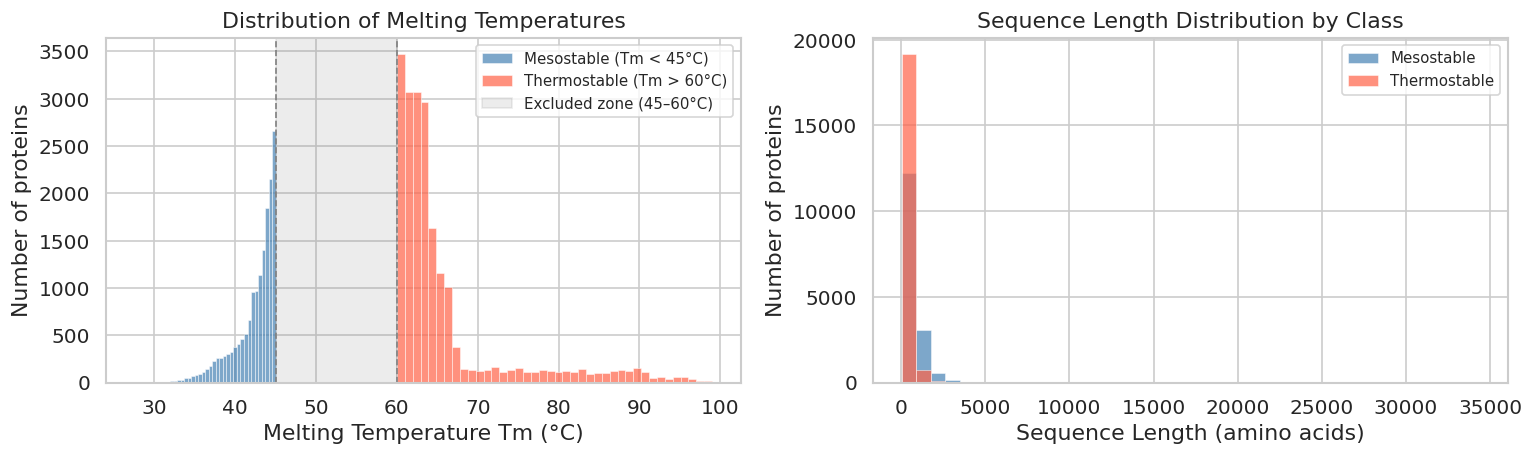

Figure saved to figures/phase1_distributions.png


In [6]:
# Create a figure with two plots side by side
# figsize=(13, 4) sets the width and height in inches
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left plot: Tm distribution coloured by class ──────────────────────────────
ax1 = axes[0]

# Plot mesostable proteins (label=0) in blue
# df[df['label']==0] filters the dataframe to only mesostable rows
ax1.hist(df[df['label']==0]['tm'], bins=40, alpha=0.7,
         color='steelblue', label='Mesostable (Tm < 45°C)',
         edgecolor='white', linewidth=0.4)

# Plot thermostable proteins (label=1) in red
ax1.hist(df[df['label']==1]['tm'], bins=40, alpha=0.7,
         color='tomato', label='Thermostable (Tm > 60°C)',
         edgecolor='white', linewidth=0.4)

# Shade the grey zone we excluded (45-60°C)
ax1.axvspan(45, 60, alpha=0.15, color='grey', label='Excluded zone (45–60°C)')
ax1.axvline(45, color='grey', linestyle='--', linewidth=1)
ax1.axvline(60, color='grey', linestyle='--', linewidth=1)

ax1.set_xlabel('Melting Temperature Tm (°C)')
ax1.set_ylabel('Number of proteins')
ax1.set_title('Distribution of Melting Temperatures')
ax1.legend(fontsize=9)

# ── Right plot: Sequence length distribution by class ─────────────────────────
ax2 = axes[1]

# First compute sequence length for every protein
# .str.len() gets the length of each string in the column
df['seq_length'] = df['sequence'].str.len()

ax2.hist(df[df['label']==0]['seq_length'], bins=40, alpha=0.7,
         color='steelblue', label='Mesostable',
         edgecolor='white', linewidth=0.4)

ax2.hist(df[df['label']==1]['seq_length'], bins=40, alpha=0.7,
         color='tomato', label='Thermostable',
         edgecolor='white', linewidth=0.4)

ax2.set_xlabel('Sequence Length (amino acids)')
ax2.set_ylabel('Number of proteins')
ax2.set_title('Sequence Length Distribution by Class')
ax2.legend(fontsize=9)

# ── Save and show ─────────────────────────────────────────────────────────────
plt.tight_layout()

# Create figures folder if it doesn't exist
os.makedirs('../figures', exist_ok=True)

# Save the figure as a PNG file
plt.savefig('../figures/phase1_distributions.png', dpi=150)
plt.show()
print("Figure saved to figures/phase1_distributions.png")

### Interpretation

**Left plot — Melting Temperature Distribution:**
- The two classes are **cleanly separated** — mesostable proteins cluster 
  between 27–44°C and thermostable proteins cluster between 61–99°C
- The **grey zone (45–60°C) is completely empty** — confirming our labelling 
  cutoffs worked correctly
- Thermostable proteins show a sharp peak around 62–65°C — this makes 
  biological sense as many thermophilic organisms live at 60–70°C
- Mesostable proteins peak around 35–40°C — consistent with proteins from 
  organisms living at normal temperatures (including humans at 37°C)

**Right plot — Sequence Length Distribution:**
- Both classes show **very similar length distributions** — both peak around 
  200–400 amino acids
- This is important! It means sequence length alone **cannot** distinguish 
  thermostable from mesostable proteins
- If the two distributions were very different, our model might just be 
  learning "longer proteins = thermostable" which would be a trivial and 
  misleading result
- Since lengths overlap heavily, our model will have to learn real 
  physicochemical patterns — which is exactly what we want

## Step 5 — Save the Clean Dataset

We already saved the clean dataset in `src/01_parse_data.py` but here we 
do a final confirmation check — verifying the file exists, has the right 
shape, and is ready to be handed to Phase 2.

This is good practice — always confirm your output files at the end of 
every phase before moving on.

In [7]:
# Confirm the saved file exists and is correct
SAVE_PATH = '../data/processed/02_dataset_clean.csv'

# os.path.exists() checks if a file exists at the given path
if os.path.exists(SAVE_PATH):
    print(f"✓ File exists: {SAVE_PATH}")
    
    # Read it back and confirm shape
    df_check = pd.read_csv(SAVE_PATH)
    print(f"✓ Shape: {df_check.shape}")
    print(f"✓ Columns: {list(df_check.columns)}")
    print(f"✓ Thermostable (label=1): {(df_check.label==1).sum():,}")
    print(f"✓ Mesostable   (label=0): {(df_check.label==0).sum():,}")
    print(f"\nDataset is ready for Phase 2 — Feature Engineering!")
else:
    print("✗ File not found! Run src/01_parse_data.py first.")

✓ File exists: ../data/processed/02_dataset_clean.csv
✓ Shape: (36100, 4)
✓ Columns: ['protein_id', 'sequence', 'tm', 'label']
✓ Thermostable (label=1): 20,051
✓ Mesostable   (label=0): 16,049

Dataset is ready for Phase 2 — Feature Engineering!


---

## Phase 1 — Summary

| Item | Details |
|------|---------|
| Dataset | Meltome Atlas (Jarzab et al. 2020, *Nature Methods*) |
| Raw proteins parsed | 201,283 |
| Grey zone dropped (45–60°C) | 165,183 |
| Final dataset size | 36,100 proteins |
| Thermostable (label=1) | 20,051 (55.5%) |
| Mesostable (label=0) | 16,049 (44.5%) |
| Class imbalance | Mild (1.25:1) — no special treatment needed |
| Missing values | None |
| Output file | `data/processed/02_dataset_clean.csv` |

## Key Takeaways

1. **The dataset is clean** — no missing values, no invalid sequences, 
   no impossible Tm values
2. **The two classes are well separated** in Tm space — our 45°C and 60°C 
   cutoffs create biologically meaningful labels
3. **Sequence length is similar across both classes** — so our ML model 
   will have to learn real physicochemical patterns, not just length
4. **Mild class imbalance** — 55.5% vs 44.5% is close enough to balanced 
   that we don't need special resampling techniques

## What comes next?

Right now each protein is just a string of letters like `MKKQTLSEW...`  
Machine learning models cannot learn from raw text — they need numbers.

**Phase 2 — Feature Engineering** will convert every sequence into a row 
of meaningful numbers using Biopython's ProtParam module. Each number will 
represent a physicochemical property of the protein — things like 
hydrophobicity, aromaticity, and amino acid composition — all of which have 
biological reasons for why they might help predict thermostability.